In [9]:
# import necessary libraries
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Implementing KNN Classifier from Scratch

In [10]:
import numpy as np

class KNN:
    def __init__(self, k):
        """
        Initialize the KNN classifier with the number of neighbors (k).
        """
        self.k = k
        self.X_train = None
        self.y_train = None

    def euclidean_distance(self, point1, point2):
        """
        Calculate the Euclidean distance between two points.
        """
        return np.sqrt(np.sum((point1 - point2) ** 2))

    def fit(self, X_train, y_train):
        """
        Store the training data for the classifier.
        """
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        """
        Predict the class for each point in the test dataset.
        """
        return np.array([self.predict_label(x) for x in X_test])

    def predict_label(self, x):
        """
        Predict the label for a single data point based on its k nearest neighbors.
        """
        # Calculate distances from x to all training points
        distances = [self.euclidean_distance(x, train_point) for train_point in self.X_train]
        # Sort the distances and get indices of the k nearest neighbors
        nearest_indices = np.argsort(distances)[:self.k]
        # Get the labels of the k nearest neighbors
        nearest_labels = [self.y_train[i] for i in nearest_indices]
        # Return the most common label among the neighbors
        return max(set(nearest_labels), key=nearest_labels.count)


Accuracy of KNN from scratch: 91.11%


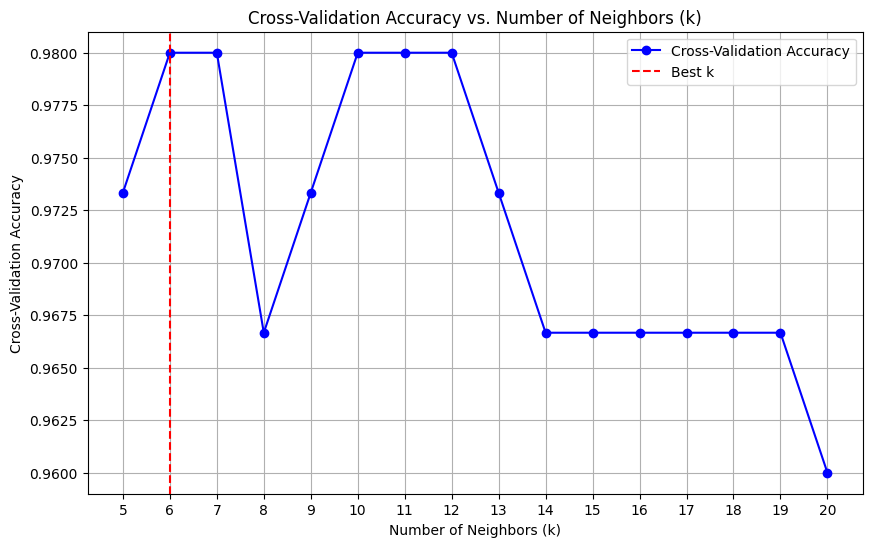

The best k value based on cross-validation is 6 with an accuracy of 98.00%


In [11]:


# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41)

# Initialize KNN classifier with k=3
knn = KNN(3)

# Fit the model
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = np.sum(y_pred == y_test) / len(y_test)

# Print accuracy
print(f"Accuracy of KNN from scratch: {accuracy * 100:.2f}%")

# Cross-validation accuracy for various k values
cross_val_accuracies = []
k_values = range(5, 21)

# Cross-validation for each k value
for k in k_values:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X, y, cv=5)  # 5-fold cross-validation
    cross_val_accuracies.append(np.mean(scores))

# Plot cross-validation accuracy vs. number of neighbors (k)
plt.figure(figsize=(10, 6))
plt.plot(k_values, cross_val_accuracies, marker='o', color='blue', label='Cross-Validation Accuracy')
plt.axvline(k_values[np.argmax(cross_val_accuracies)], color='red', linestyle='--', label='Best k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Cross-Validation Accuracy vs. Number of Neighbors (k)')
plt.xticks(k_values)
plt.legend()
plt.grid()
plt.show()

# Find the best k value based on cross-validation
best_k_cv = k_values[np.argmax(cross_val_accuracies)]
print(f'The best k value based on cross-validation is {best_k_cv} with an accuracy of {max(cross_val_accuracies) * 100:.2f}%')

